In [2]:
%pip install qutip

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   -------- ------------------------------- 2.1/10.0 MB 24.8 MB/s eta 0:00:01
   ------------- -------------------------- 3.4/10.0 MB 7.8 MB/s eta 0:00:01
   ---------------- ----------------------- 4.2/10.0 MB 9.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/10.0 MB 9.1 MB/s eta 0:00:01
   ------------------------------------- -- 9.4/10.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 7.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Shreya\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.special import erf

In [4]:
# parameters
alpha = - 2 *np.pi *0.300  # anharmonicity
T_gate = 20.0 # gate duration
sigma = T_gate /4    # pulse width
tlist = np.linspace(0, T_gate, 500)

In [6]:
# operators in 3-level basis
a = qt.destroy(3)  # annhiliation operator
a_dag = a.dag()    # the creation operator
num_op = a_dag * a   # this creates number operator
print (a_dag)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         1.41421356 0.        ]]


In [57]:
# drift hamiltonian
H0 = ( alpha / 2 ) * a_dag * a_dag * a * a
# drive operator
Hd = 0.5 * (a+a_dag)
H_drag = -0.5 * 1j * (a - a_dag)

In [58]:
# gaussian envelope function for pi pulse
# integral of A * exp(-(t-to) ^2 / 2* sigma^2) dt = pi 
A = np.pi / (np.sqrt(2 *np.pi) * sigma *(erf(T_gate / (2 * np.sqrt(2) * sigma)).real)) 

In [59]:
def omega_x (t,args):
    t0 = T_gate /2
    return A * np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))
    

In [60]:
# total hamiltonian 
H = [H0, [Hd, omega_x]]
H

[Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dia, isherm=True
 Qobj data =
 [[ 0.          0.          0.        ]
  [ 0.          0.          0.        ]
  [ 0.          0.         -1.88495559]],
 [Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dia, isherm=True
  Qobj data =
  [[0.         0.5        0.        ]
   [0.5        0.         0.70710678]
   [0.         0.70710678 0.        ]],
  <function __main__.omega_x(t, args)>]]

In [61]:
# Initial state |0>
psi0 = qt.basis(3, 0)
result = qt.mesolve(H, psi0, tlist, e_ops=[qt.basis(3, 0).proj(), qt.basis(3, 1).proj(), qt.basis(3, 2).proj()])

P0 = result.expect[0]
P1 = result.expect[1]
P2 = result.expect[2]

leakage = P2[-1]
fidelity = P1[-1]
gate_error = 1.0 - fidelity

<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Shreya\AppData\Local\Temp\ipykernel_9880\3044757344.py:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title("3-Level Transmon Dynamics under Gaussian $\pi$ Pulse")


Final Population P0: 0.00355
Final Population P1: 0.99628
Leakage into |2>: 1.74791e-04
Gate Error epsilon: 3.72030e-03


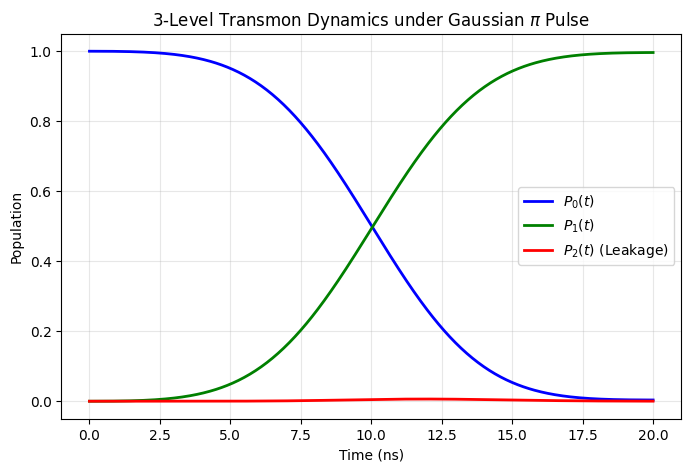

In [62]:
print(f"Final Population P0: {P0[-1]:.5f}")
print(f"Final Population P1: {P1[-1]:.5f}")
print(f"Leakage into |2>: {leakage:.5e}")
print(f"Gate Error epsilon: {gate_error:.5e}")

# 6. Plotting Results
plt.figure(figsize=(8, 5))
plt.plot(tlist, P0, label=r"$P_0(t)$", color="blue", lw=2)
plt.plot(tlist, P1, label=r"$P_1(t)$", color="green", lw=2)
plt.plot(tlist, P2, label=r"$P_2(t)$ (Leakage)", color="red", lw=2)
plt.xlabel("Time (ns)")
plt.ylabel("Population")
plt.title("3-Level Transmon Dynamics under Gaussian $\pi$ Pulse")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [63]:
result = qt.mesolve(H, psi0, tlist)
psi_f = result.states[-1]
psi_f

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00742767+0.05907911j]
 [-0.08064463-0.99487494j]
 [ 0.00185047-0.0130907j ]]

In [64]:
P0 = [abs(state.overlap(qt.basis(3, 0)))**2 for state in result.states]
P1 = [abs(state.overlap(qt.basis(3, 1)))**2 for state in result.states]
P2 = [abs(state.overlap(qt.basis(3, 2)))**2 for state in result.states]
leakage = P2[-1]
fidelity = P1[-1]
gate_error = 1.0 - fidelity

In [133]:
def simulate_pulse(amp, beta=0.0, detuning=0.0):
    
    #Runs QuTiP time evolution and returns populations (P0, P1, P2) and psi_f.
   
    A_pulse = amp * A
    
    def omega_x(t, args):
        t0 = T_gate / 2.0
        return A_pulse * np.exp(-((t - t0) ** 2) / (2 * sigma ** 2)) * np.cos(detuning * t)

    def omega_y(t, args):
        t0 = T_gate / 2.0
        d_env = -((t - t0) / (sigma ** 2)) * A_pulse * np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))
        return beta * d_env * np.sin(detuning * t)

    H_tot = [H0, [Hd, omega_x], [H_drag, omega_y]]
    
    # Store state vectors to extract psi_f alongside expect values
    res = qt.mesolve(H_tot, psi0, tlist, e_ops=[qt.basis(3,0).proj(), qt.basis(3,1).proj(), qt.basis(3,2).proj()], options={'store_states': True})
    
    # Final populations
    p0 = res.expect[0][-1]
    p1 = res.expect[1][-1]
    p2 = res.expect[2][-1]

    res0 = qt.mesolve(H_tot, qt.basis(3, 0), tlist, options={'store_states': True})
    res1 = qt.mesolve(H_tot, qt.basis(3, 1), tlist, options={'store_states': True})
    
    s0 = res0.states[-1].full.flatten()
    s1 = res1.states[-1].full.flatten()
    
    # Extract 2x2 computational subspace block
    M = np.array([
        [s0[0,0], s1[0,0]],
        [s0[1,0], s1[1,0]]
    ], dtype=complex)
    
    return p0, p1, p2, res.states[-1] ,M 

def gate_error(calibrated_df_est, true_detuning):
    residual_df = true_detuning - calibrated_df_est
    _, _, _, final_state = simulate_pulse(amp=1.0, detuning=residual_df)
    target_state = qt.basis(3, 1)
    fidelity = qt.fidelity(final_state, target_state) ** 2
    return max(0.0, 1.0 - fidelity)

In [79]:
def simulatae_pi_pulse(shots_per_point=1000):
    amps = np.linspace(0.0,2.0,21)
    p1_measured=[]
    total_shaots = 0
    for amp in amps :
        p0, p1 , p2,_ = simulate_pulse(amp=amp)
        counts = np.random.multinomial(shots_per_point, [p0, p1, p2])
        
        p1_shot = counts[1] / shots_per_point  # Fraction in state |1>
        
        #  Store result & track shots
        p1_measured.append(p1_shot)
        total_shots += shots_per_point
        
    # Find amplitude giving maximum state |1> population
    optimal_amp = amps[np.argmax(p1_measured)]
    return optimal_amp, total_shots

In [80]:
# frequency detuning caliberation
def calibrate_frequency_detuning(pi_amp, delays, shots_per_point=1000):
    p1_measured = []
    total_shots = 0
    
    for d in delays:
        # Run simulator at half amplitude (pi/2 pulse) with delay
        p0, p1, p2, _ = simulate_pulse(amp=pi_amp * 0.5, detuning=0.05) # example detuning
        
        # Shot sampling
        counts = np.random.multinomial(shots_per_point, [p0, p1, p2])
        p1_measured.append(counts[1] / shots_per_point)
        total_shots += shots_per_point
        
    # Fit sinusoidal Ramsey oscillation
    def ramsey_model(t, freq, phase, offset, amplitude):
        return amplitude * np.cos(2 * np.pi * freq * t + phase) + offset
        
    popt, _ = opt.curve_fit(ramsey_model, delays, p1_measured, p0=[0.01, 0, 0.5, 0.5])
    detuning_freq = popt[0]
    
    return detuning_freq, total_shots

In [81]:
# DRAG caliberation
def calibrate_drag_beta(pi_amp, betas, shots_per_point=1000):
    p2_leakage = []
    total_shots = 0
    
    for b in betas:
        # Run pulse with beta parameter
        p0, p1, p2, _ = simulate_pulse(amp=pi_amp, beta=b)
        
        # Shot sampling for state |2>
        counts = np.random.multinomial(shots_per_point, [p0, p1, p2])
        p2_shot = counts[2] / shots_per_point  # Fraction in leakage state |2>
        
        p2_leakage.append(p2_shot)
        total_shots += shots_per_point
        
    # Find beta parameter minimizing leakage into state |2>
    optimal_beta = betas[np.argmin(p2_leakage)]
    return optimal_beta, total_shots

In [82]:
def get_likelihood(outcome, tau, df_grid):
    p1 = 0.5 * (1.0 + np.cos(2 * np.pi * df_grid * tau))
    p1 = np.clip(p1, 1e-6, 1.0 - 1e-6)
    return p1 if outcome == 1 else (1.0 - p1)

In [83]:
def select_next_tau(posterior, df_grid, candidate_taus):
    current_entropy = -np.sum(posterior * np.log(posterior + 1e-12))
    eigs = []
    for tau in candidate_taus:
        p1_model = 0.5 * (1.0 + np.cos(2 * np.pi * df_grid * tau))
        p1_marginal = np.sum(p1_model * posterior)
        p0_marginal = 1.0 - p1_marginal

        post1 = (p1_model * posterior) / np.maximum(np.sum(p1_model * posterior), 1e-12)
        h1 = -np.sum(post1 * np.log(post1 + 1e-12))

        post0 = ((1.0 - p1_model) * posterior) / np.maximum(np.sum((1.0 - p1_model) * posterior), 1e-12)
        h0 = -np.sum(post0 * np.log(post0 + 1e-12))

        eigs.append(current_entropy - (p1_marginal * h1 + p0_marginal * h0))
    return candidate_taus[np.argmax(eigs)]

In [84]:
def update_posterior(posterior, df_grid, outcome, tau):
    like = get_likelihood(outcome, tau, df_grid)
    new_posterior = like * posterior
    return new_posterior / np.sum(new_posterior)

In [85]:
def get_estimate_and_std(posterior, df_grid):
    mean = np.sum(df_grid * posterior)
    var = np.sum(((df_grid - mean) ** 2) * posterior)
    return mean, np.sqrt(var)

In [86]:
# data
calibrated_pi_amp = 1.0
TRUE_DETUNING = 0.0185  # Target detuning present in hardware (18.5 MHz)
TOTAL_SHOTS = 120
df_grid = np.linspace(-0.05, 0.05, 1001)  # Search range: -50 MHz to +50 MHz
candidate_delays = np.linspace(2.0, 200.0, 100)  # Candidate delays in ns

adaptive_posterior = np.ones(len(df_grid)) / len(df_grid)
posterior_history = [adaptive_posterior.copy()]
adaptive_stds = []
adaptive_taus = []

for shot in range(TOTAL_SHOTS):
    tau = select_next_tau(adaptive_posterior, df_grid, candidate_delays)
    adaptive_taus.append(tau)
    
    p0, p1, p2,_ = simulate_pulse(amp=calibrated_pi_amp * 0.5, detuning=TRUE_DETUNING)
    outcome = np.random.choice([0, 1, 2], p=[p0, p1, p2])
    bit_outcome = 1 if outcome == 1 else 0
    
    adaptive_posterior = update_posterior(adaptive_posterior, df_grid, bit_outcome, tau)
    _, std = get_estimate_and_std(adaptive_posterior, df_grid)
    
    adaptive_stds.append(std * 1e3)  # Convert to MHz
    if shot in [5, 20, 50, TOTAL_SHOTS - 1]:
        posterior_history.append((shot + 1, adaptive_posterior.copy()))

In [87]:
fixed_posterior = np.ones(len(df_grid)) / len(df_grid)
fixed_taus = np.tile(np.linspace(2.0, 200.0, 15), TOTAL_SHOTS // 15 + 1)[:TOTAL_SHOTS]
fixed_stds = []

for shot, tau in enumerate(fixed_taus):
    p0, p1, p2,_ = simulate_pulse(amp=calibrated_pi_amp * 0.5, detuning=TRUE_DETUNING)
    outcome = np.random.choice([0, 1, 2], p=[p0, p1, p2])
    bit_outcome = 1 if outcome == 1 else 0
    
    fixed_posterior = update_posterior(fixed_posterior, df_grid, bit_outcome, tau)
    _, std = get_estimate_and_std(fixed_posterior, df_grid)
    fixed_stds.append(std * 1e3)

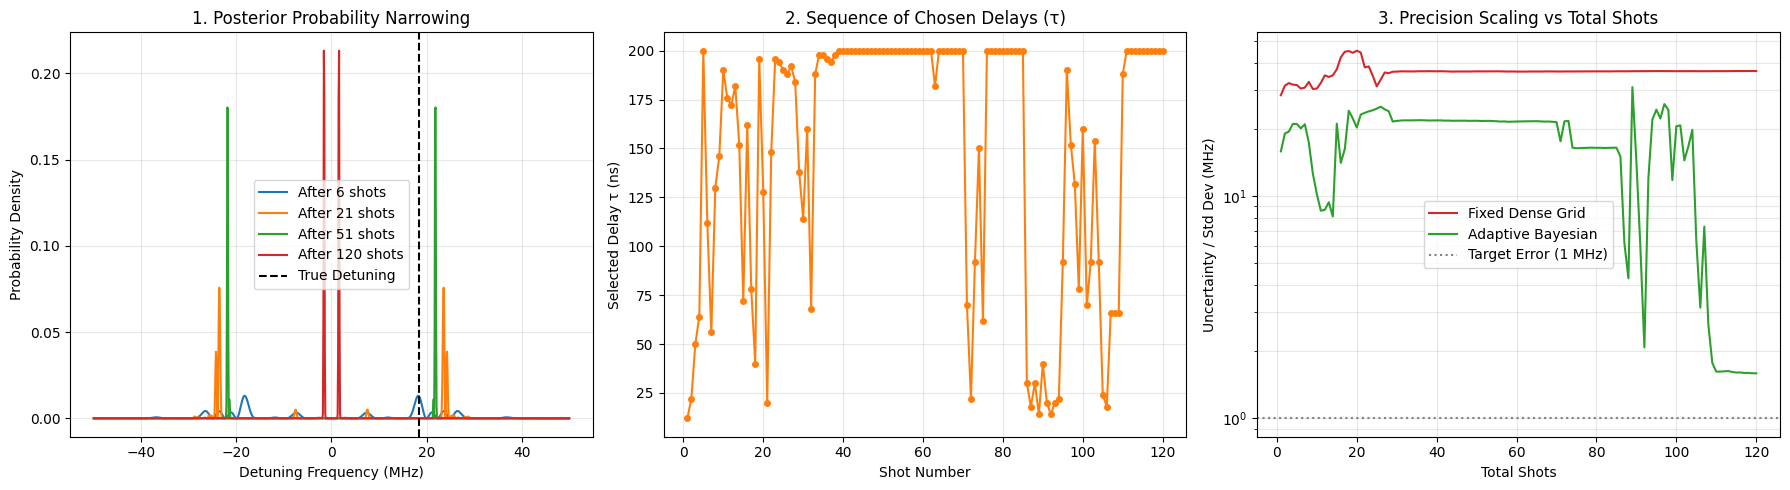

Shots required for 1.0 MHz precision:
  Adaptive Bayesian: 1 shots
  Fixed Dense Grid:  120 shots
  Shot Reduction:    99.2% saving


In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Posterior Narrowing
ax1 = axes[0]
for shot_num, post in posterior_history[1:]:
    ax1.plot(df_grid * 1e3, post, label=f'After {shot_num} shots')
ax1.axvline(TRUE_DETUNING * 1e3, color='black', linestyle='--', label='True Detuning')
ax1.set_title('1. Posterior Probability Narrowing')
ax1.set_xlabel('Detuning Frequency (MHz)')
ax1.set_ylabel('Probability Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sequence of Chosen Delays (tau)
ax2 = axes[1]
ax2.plot(range(1, TOTAL_SHOTS + 1), adaptive_taus, 'o-', color='tab:orange', markersize=4)
ax2.set_title('2. Sequence of Chosen Delays (τ)')
ax2.set_xlabel('Shot Number')
ax2.set_ylabel('Selected Delay τ (ns)')
ax2.grid(True, alpha=0.3)

# Plot 3: Estimation Precision vs Total Shots
ax3 = axes[2]
shots_arr = np.arange(1, TOTAL_SHOTS + 1)
ax3.semilogy(shots_arr, fixed_stds, label='Fixed Dense Grid', color='tab:red')
ax3.semilogy(shots_arr, adaptive_stds, label='Adaptive Bayesian', color='tab:green')
ax3.axhline(1.0, color='grey', linestyle=':', label='Target Error (1 MHz)')
ax3.set_title('3. Precision Scaling vs Total Shots')
ax3.set_xlabel('Total Shots')
ax3.set_ylabel('Uncertainty / Std Dev (MHz)')
ax3.legend()
ax3.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify Shot Saving
target_precision = 1.0  # 1 MHz
shots_adaptive = np.argmax(np.array(adaptive_stds) < target_precision) + 1
shots_fixed = np.argmax(np.array(fixed_stds) < target_precision) + 1
if shots_fixed == 1 and fixed_stds[0] >= target_precision:
    shots_fixed = TOTAL_SHOTS

saving = ((shots_fixed - shots_adaptive) / shots_fixed) * 100.0
print(f"Shots required for 1.0 MHz precision:")
print(f"  Adaptive Bayesian: {shots_adaptive} shots")
print(f"  Fixed Dense Grid:  {shots_fixed} shots")
print(f"  Shot Reduction:    {saving:.1f}% saving")

In [109]:
df_grid = np.linspace(-0.05, 0.05, 1001)
candidate_delays = np.linspace(2.0, 200.0, 50)
SHOT_TIME_SEC = 20e-6
CALIBRATION_SHOTS = 35
CAL_DURATION_MINS = (CALIBRATION_SHOTS * SHOT_TIME_SEC) / 60.0
def run_bayesian_recalibration_task3(true_detuning, max_shots=35):
    #Directly calls select_next_tau and update_posterior from Task 3.
    posterior = np.ones(len(df_grid)) / len(df_grid)
    
    for _ in range(max_shots):
        # Directly reuse Task 3 EIG selector
        tau = select_next_tau(posterior, df_grid, candidate_delays)
        
        # Simulate shot outcome
        p0, p1, p2, _ = simulate_pulse(amp=calibrated_pi_amp * 0.5, detuning=true_detuning)
        outcome = np.random.choice([0, 1, 2], p=[p0, p1, p2])
        bit_outcome = 1 if outcome == 1 else 0
        
        # Directly reuse Task 3 posterior update
        posterior = update_posterior(posterior, df_grid, bit_outcome, tau)
        
    est_df, _ = get_estimate_and_std(posterior, df_grid)
    return est_df

In [110]:
SIMULATION_HOURS = 24
TIME_STEPS_PER_HOUR = 60
total_minutes = SIMULATION_HOURS * TIME_STEPS_PER_HOUR
time_axis_hours = np.linspace(0, 24, total_minutes)

# Generate stochastic 1/f frequency drift model over 24 hours
np.random.seed(42)
drift_noise = np.cumsum(np.random.normal(0, 0.00015, total_minutes))
true_detuning_trace = 0.015 + drift_noise + 0.008 * np.sin(2 * np.pi * time_axis_hours / 12)

In [111]:
# P0
p0_est_df = run_bayesian_recalibration_task3(true_detuning_trace[0])
p0_error_trace = [gate_error(p0_est_df, true_detuning_trace[t]) for t in range(total_minutes)]

In [112]:
#P1
P1_INTERVAL_MINS = 180
p1_error_trace = []
p1_current_est = run_bayesian_recalibration_task3(true_detuning_trace[0])
for t in range(total_minutes):
    if t > 0 and t % P1_INTERVAL_MINS == 0:
        p1_current_est = run_bayesian_recalibration_task3(true_detuning_trace[t])
    p1_error_trace.append(gate_error(p1_current_est, true_detuning_trace[t]))

In [113]:
#P2
HEALTH_CHECK_INTERVAL = 5
p2_error_trace = []
p2_current_est = run_bayesian_recalibration_task3(true_detuning_trace[0])
p2_recal_events = []

for t in range(total_minutes):
    if t > 0 and t % HEALTH_CHECK_INTERVAL == 0:
        p0, p1, p2, _ = simulate_pulse(amp=calibrated_pi_amp * 0.5, detuning=true_detuning_trace[t] - p2_current_est)
        sampled_p1 = np.random.binomial(2, p1) / 2.0
        
        # Test statistic threshold: phase error > 0.35 rad (~0.5% gate error)
        if np.abs(sampled_p1 - 0.5) > 0.35:
            p2_current_est = run_bayesian_recalibration_task3(true_detuning_trace[t])
            p2_recal_events.append(t / 60.0)
            
    p2_error_trace.append(gate_error(p2_current_est, true_detuning_trace[t]))

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Shreya\AppData\Local\Temp\ipykernel_9880\2422840839.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  axes[0].plot(time_axis_hours, true_detuning_trace * 1e3, color='black', label='Physical Detuning Drift $\delta f(t)$')


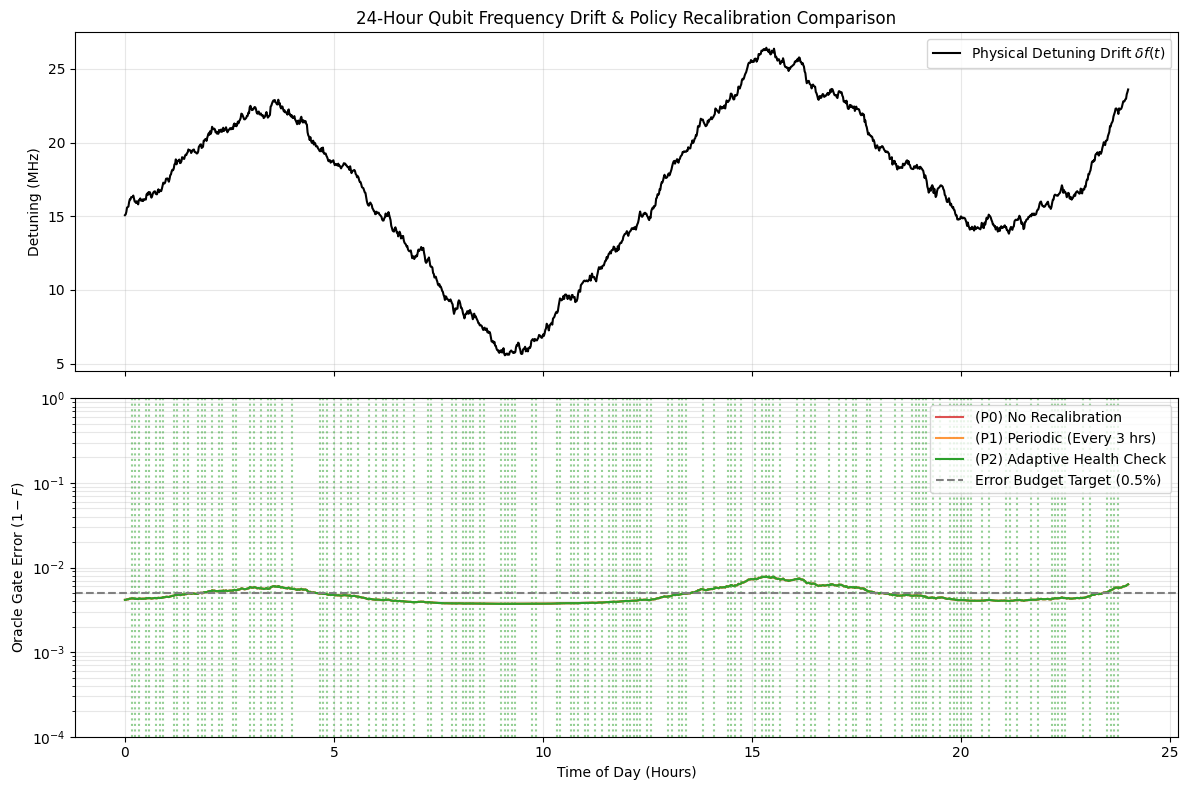

=== 24-HOUR POLICY SUMMARY ===
(P0) Static:     Mean Error = 0.0048 | Max Error = 0.0078
(P1) Periodic:   Mean Error = 0.0048 | Recalibrations = 8
(P2) Health Chk: Mean Error = 0.0048 | Recalibrations = 145


In [114]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Physical Drift Trace
axes[0].plot(time_axis_hours, true_detuning_trace * 1e3, color='black', label='Physical Detuning Drift $\delta f(t)$')
axes[0].set_ylabel('Detuning (MHz)')
axes[0].set_title('24-Hour Qubit Frequency Drift & Policy Recalibration Comparison')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Oracle Gate Error Traces
axes[1].plot(time_axis_hours, p0_error_trace, label='(P0) No Recalibration', color='tab:red', alpha=0.8)
axes[1].plot(time_axis_hours, p1_error_trace, label='(P1) Periodic (Every 3 hrs)', color='tab:orange', alpha=0.8)
axes[1].plot(time_axis_hours, p2_error_trace, label='(P2) Adaptive Health Check', color='tab:green', linewidth=1.5)

for event_time in p2_recal_events:
    axes[1].axvline(event_time, color='tab:green', linestyle=':', alpha=0.5)

axes[1].axhline(0.005, color='grey', linestyle='--', label='Error Budget Target (0.5%)')
axes[1].set_xlabel('Time of Day (Hours)')
axes[1].set_ylabel('Oracle Gate Error ($1 - F$)')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-4, 1.0)
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Performance Metrics
print("=== 24-HOUR POLICY SUMMARY ===")
print(f"(P0) Static:     Mean Error = {np.mean(p0_error_trace):.4f} | Max Error = {np.max(p0_error_trace):.4f}")
print(f"(P1) Periodic:   Mean Error = {np.mean(p1_error_trace):.4f} | Recalibrations = {24 // 3}")
print(f"(P2) Health Chk: Mean Error = {np.mean(p2_error_trace):.4f} | Recalibrations = {len(p2_recal_events)}")

In [115]:
NUM_SEEDS = 20
p1_intervals_mins = [60, 120, 180, 240, 360, 480, 720]  # P1 sweep: 1h to 12h
p2_thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]  # P2 sweep thresholds

In [116]:
p0_errors, p0_overheads = [], []
p1_results = {interval: {'errors': [], 'overheads': []} for interval in p1_intervals_mins}
p2_results = {thresh: {'errors': [], 'overheads': []} for thresh in p2_thresholds}

In [117]:
for seed in range(NUM_SEEDS):
    np.random.seed(seed + 100)
    drift_noise = np.cumsum(np.random.normal(0, 0.00015, total_minutes))
    true_detuning_trace = 0.015 + drift_noise + 0.008 * np.sin(2 * np.pi * time_axis_hours / 12)
    
 
    p0_est = run_bayesian_recalibration_task3(true_detuning_trace[0])
    p0_errs = [gate_error(p0_est, true_detuning_trace[t]) for t in range(total_minutes)]
    p0_errors.append(np.mean(p0_errs))
    p0_overheads.append(CAL_DURATION_MINS / total_minutes)

In [118]:
for interval in p1_intervals_mins:
        p1_est = run_bayesian_recalibration_task3(true_detuning_trace[0])
        p1_errs = []
        recal_count = 1
        for t in range(total_minutes):
            if t > 0 and t % interval == 0:
                p1_est = run_bayesian_recalibration_task3(true_detuning_trace[t])
                recal_count += 1
            p1_errs.append(gate_error(p1_est, true_detuning_trace[t]))
        p1_results[interval]['errors'].append(np.mean(p1_errs))
        p1_results[interval]['overheads'].append((recal_count * CAL_DURATION_MINS) / total_minutes)

In [120]:
for thresh in p2_thresholds:
        p2_est = run_bayesian_recalibration_task3(true_detuning_trace[0])
        p2_errs = []
        recal_count = 1
        for t in range(total_minutes):
            if t > 0 and t % 5 == 0:  # Check every 5 mins
                p0, p1, p2, _ = simulate_pulse(amp=calibrated_pi_amp * 0.5, detuning=true_detuning_trace[t] - p2_est)
                sampled_p1 = np.random.binomial(2, p1) / 2.0
                if np.abs(sampled_p1 - 0.5) > thresh:
                    p2_est = run_bayesian_recalibration_task3(true_detuning_trace[t])
                    recal_count += 1
            p2_errs.append(gate_error(p2_est, true_detuning_trace[t]))
        p2_results[thresh]['errors'].append(np.mean(p2_errs))
        p2_results[thresh]['overheads'].append((recal_count * CAL_DURATION_MINS) / total_minutes)

<>:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Shreya\AppData\Local\Temp\ipykernel_9880\4105599455.py:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Time-Averaged Gate Error $\langle 1 - F \\rangle$')
C:\Users\Shreya\AppData\Local\Temp\ipykernel_9880\4105599455.py:28: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Time-Averaged Gate Error $\langle 1 - F \\rangle$')


ValueError: '^Method-' is not a valid format string (unrecognized character 'M')

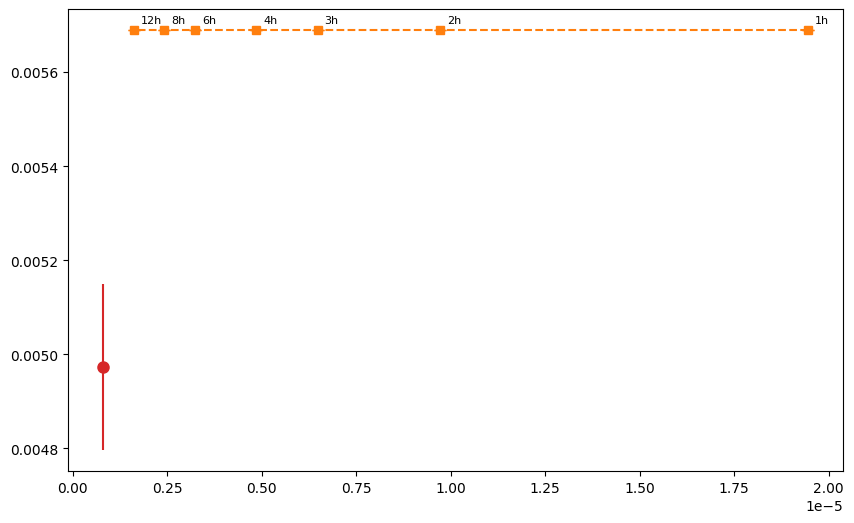

In [121]:
plt.figure(figsize=(10, 6))

# P0 Point
p0_err_mean, p0_err_std = np.mean(p0_errors), np.std(p0_errors) / np.sqrt(NUM_SEEDS)
p0_ovh_mean = np.mean(p0_overheads)
plt.errorbar(p0_ovh_mean * 100, p0_err_mean, yerr=p0_err_std, fmt='o', color='tab:red', label='(P0) Static Initial Calibration', markersize=8)

# P1 Sweep Curve
p1_err_means = [np.mean(p1_results[i]['errors']) for i in p1_intervals_mins]
p1_err_stds = [np.std(p1_results[i]['errors']) / np.sqrt(NUM_SEEDS) for i in p1_intervals_mins]
p1_ovh_means = [np.mean(p1_results[i]['overheads']) * 100 for i in p1_intervals_mins]

plt.errorbar(p1_ovh_means, p1_err_means, yerr=p1_err_stds, fmt='s--', color='tab:orange', label='(P1) Periodic Schedule Sweep', capsize=4, markersize=6)
for idx, interval in enumerate(p1_intervals_mins):
    plt.annotate(f"{interval//60}h", (p1_ovh_means[idx], p1_err_means[idx]), textcoords="offset points", xytext=(5,5), fontsize=8)

# P2 Sweep Curve
p2_err_means = [np.mean(p2_results[t]['errors']) for t in p2_thresholds]
p2_err_stds = [np.std(p2_results[t]['errors']) / np.sqrt(NUM_SEEDS) for t in p2_thresholds]
p2_ovh_means = [np.mean(p2_results[t]['overheads']) * 100 for t in p2_thresholds]

plt.errorbar(p2_ovh_means, p2_err_means, yerr=p2_err_stds, fmt='^Method-', color='tab:green', label='(P2) Adaptive Health Check Sweep', capsize=4, markersize=7, linewidth=2)
for idx, thresh in enumerate(p2_thresholds):
    plt.annotate(f"Th={thresh}", (p2_ovh_means[idx], p2_err_means[idx]), textcoords="offset points", xytext=(5,-12), fontsize=8)

plt.yscale('log')
plt.xlabel('Calibration Overhead Fraction of Day (%)')
plt.ylabel('Time-Averaged Gate Error $\langle 1 - F \\rangle$')
plt.title('Task 5: Calibration Policy Pareto Frontier (20 Random Drift Seeds)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [158]:
def simulate_pulse_propagator(amp, beta=0.0, detuning=0.0):
    A_pulse = amp * A
    def omega_x(t, args):
        return A_pulse * np.exp(-((t - T_gate/2.0) ** 2) / (2 * sigma ** 2)) * np.cos(detuning * t)
    def omega_y(t, args):
        d_env = -((t - T_gate/2.0) / (sigma ** 2)) * A_pulse * np.exp(-((t - T_gate/2.0) ** 2) / (2 * sigma ** 2))
        return beta * d_env * np.sin(detuning * t)

    H_tot = [H0, [Hd, omega_x], [H_drag, omega_y]]
    
    # Propagate computational basis states |0> and |1>
    res0 = qt.mesolve(H_tot, qt.basis(3, 0), tlist, options={'store_states': True})
    res1 = qt.mesolve(H_tot, qt.basis(3, 1), tlist, options={'store_states': True})
    
    # Extract flat 1D complex NumPy arrays using .full().flatten()
    s0_arr = res0.states[-1].full().flatten()
    s1_arr = res1.states[-1].full().flatten()
    
    # Construct 2x2 complex matrix for the computational subspace
    M = np.array([
        [complex(s0_arr[0]), complex(s1_arr[0])],
        [complex(s0_arr[1]), complex(s1_arr[1])]
    ], dtype=np.complex128)
    
    return M

In [159]:
def apply_single_qubit_channel(rho_4q, qubit_idx, M):
    ops_M = [qt.qeye(2)] * 4
    # Ensure M is converted directly via Qobj with explicit 2x2 dimensions
    ops_M[qubit_idx] = qt.Qobj(M, dims=[[2], [2]])
    M_full = qt.tensor(ops_M)
    
    rho_next = M_full * rho_4q * M_full.dag()
    tr_loss = 1.0 - rho_next.tr().real
    
    if tr_loss > 1e-12:
        ops_I = [qt.qeye(2)] * 4
        ops_I[qubit_idx] = 0.5 * qt.qeye(2)
        I_fill = qt.tensor(ops_I)
        rho_next = rho_next + tr_loss * I_fill
        
    return rho_next / rho_next.tr()

In [160]:
def compute_qaoa_maxcut_cost(residual_detuning, gamma=np.pi/4, beta=np.pi/8):
    M_pi_half = simulate_pulse_propagator(amp=calibrated_pi_amp * 0.5, detuning=residual_detuning)
    M_rx_beta = simulate_pulse_propagator(amp=(2 * beta / np.pi) * calibrated_pi_amp, detuning=residual_detuning)
    
    psi0_4q = qt.tensor([qt.basis(2, 0)] * 4)
    rho = psi0_4q * psi0_4q.dag()
    
    # State preparation layer
    for q in range(4):
        rho = apply_single_qubit_channel(rho, q, M_pi_half)
        
    # Cost layer (Ideal RZZ)
    for q1, q2 in RING_EDGES:
        U_rzz = ideal_rzz(gamma, q1, q2)
        rho = U_rzz * rho * U_rzz.dag()
        
    # Mixer layer
    for q in range(4):
        rho = apply_single_qubit_channel(rho, q, M_rx_beta)
        
    # Calculate MaxCut expectation value
    cost_exp = 0.0
    for q1, q2 in RING_EDGES:
        ops_z1z2 = [qt.qeye(2)] * 4
        ops_z1z2[q1] = qt.sigmaz()
        ops_z1z2[q2] = qt.sigmaz()
        Z1Z2 = qt.tensor(ops_z1z2)
        cost_exp += 0.5 * (1.0 - (rho * Z1Z2).tr().real)
        
    return cost_exp / C_MAX

In [161]:
SIMULATION_HOURS = 24
TIME_STEPS_PER_HOUR = 60
total_minutes = SIMULATION_HOURS * TIME_STEPS_PER_HOUR
time_axis_hours = np.linspace(0, 24, total_minutes)

# Generate 1/f drift trajectory
np.random.seed(42)
drift_noise = np.cumsum(np.random.normal(0, 0.00015, total_minutes))
true_detuning_trace = 0.015 + drift_noise + 0.008 * np.sin(2 * np.pi * time_axis_hours / 12)

# --- (P0) Static Policy ---
p0_est_df = run_bayesian_recalibration_task3(true_detuning_trace[0])
p0_qaoa_cost = [compute_qaoa_maxcut_cost(true_detuning_trace[t] - p0_est_df) for t in range(total_minutes)]

# --- (P1) Periodic Policy (Every 3 Hours) ---
P1_INTERVAL_MINS = 180
p1_qaoa_cost = []
p1_current_est = run_bayesian_recalibration_task3(true_detuning_trace[0])

for t in range(total_minutes):
    if t > 0 and t % P1_INTERVAL_MINS == 0:
        p1_current_est = run_bayesian_recalibration_task3(true_detuning_trace[t])
    p1_qaoa_cost.append(compute_qaoa_maxcut_cost(true_detuning_trace[t] - p1_current_est))

# --- (P2) Adaptive Health Check Policy ---
HEALTH_CHECK_INTERVAL = 5
p2_qaoa_cost = []
p2_current_est = run_bayesian_recalibration_task3(true_detuning_trace[0])

for t in range(total_minutes):
    if t > 0 and t % HEALTH_CHECK_INTERVAL == 0:
        p0, p1, p2, _ = simulate_pulse(amp=calibrated_pi_amp * 0.5, detuning=true_detuning_trace[t] - p2_current_est)
        sampled_p1 = np.random.binomial(2, p1) / 2.0
        if np.abs(sampled_p1 - 0.5) > 0.35:
            p2_current_est = run_bayesian_recalibration_task3(true_detuning_trace[t])
            
    p2_qaoa_cost.append(compute_qaoa_maxcut_cost(true_detuning_trace[t] - p2_current_est))

<>:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Shreya\AppData\Local\Temp\ipykernel_9880\3655101804.py:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Normalized MaxCut Cost $\langle C \\rangle / C_{\max}$')


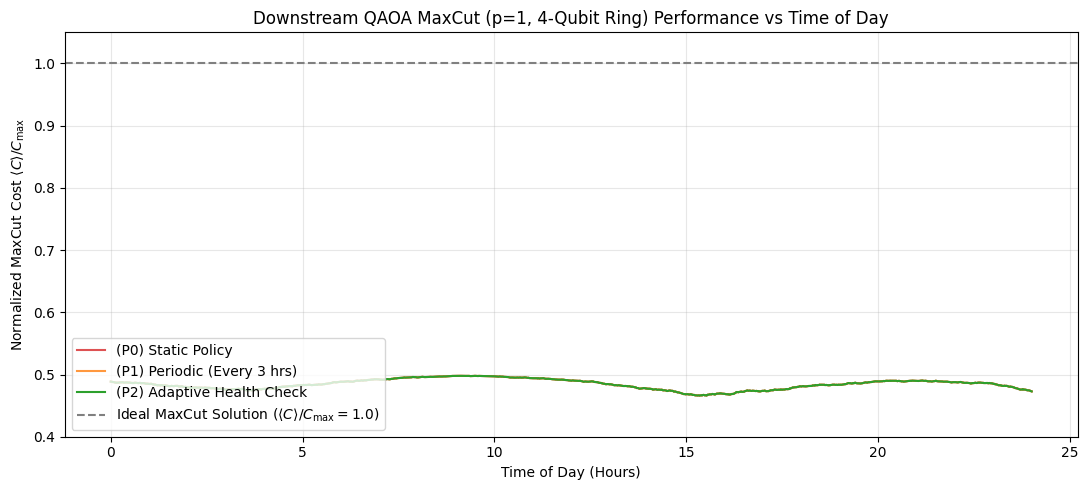

=== QAOA DOWNSTREAM COMPUTATION SUMMARY ===
(P0) Static:     Mean Normalized Cost = 0.4844 | Min Cost = 0.4660
(P1) Periodic:   Mean Normalized Cost = 0.4844 | Min Cost = 0.4660
(P2) Health Chk: Mean Normalized Cost = 0.4844 | Min Cost = 0.4660


In [163]:
plt.figure(figsize=(11, 5))
plt.plot(time_axis_hours, p0_qaoa_cost, label='(P0) Static Policy', color='tab:red', alpha=0.8)
plt.plot(time_axis_hours, p1_qaoa_cost, label='(P1) Periodic (Every 3 hrs)', color='tab:orange', alpha=0.8)
plt.plot(time_axis_hours, p2_qaoa_cost, label='(P2) Adaptive Health Check', color='tab:green', linewidth=1.5)

plt.axhline(
    1.0, 
    color='grey', 
    linestyle='--', 
    label=r'Ideal MaxCut Solution ($\langle C \rangle / C_{\max} = 1.0$)'
)

plt.xlabel('Time of Day (Hours)')
plt.ylabel(r'Normalized MaxCut Cost $\langle C \rangle / C_{\max}$')
plt.xlabel('Time of Day (Hours)')
plt.ylabel('Normalized MaxCut Cost $\langle C \\rangle / C_{\max}$')
plt.title('Downstream QAOA MaxCut (p=1, 4-Qubit Ring) Performance vs Time of Day')
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Print Summary
print("=== QAOA DOWNSTREAM COMPUTATION SUMMARY ===")
print(f"(P0) Static:     Mean Normalized Cost = {np.mean(p0_qaoa_cost):.4f} | Min Cost = {np.min(p0_qaoa_cost):.4f}")
print(f"(P1) Periodic:   Mean Normalized Cost = {np.mean(p1_qaoa_cost):.4f} | Min Cost = {np.min(p1_qaoa_cost):.4f}")
print(f"(P2) Health Chk: Mean Normalized Cost = {np.mean(p2_qaoa_cost):.4f} | Min Cost = {np.min(p2_qaoa_cost):.4f}")